In [1]:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1> Treinando o algoritmo de clusterização Agglomerative Clustering</h1>

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "iris.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "himanshunakrani/iris-dataset",
  file_path
)

print("First 5 records:", df.head())

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\maria\AppData\Local\Temp\ipykernel_8912\220261672.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
from sklearn.cluster import AgglomerativeClustering

def aplicar_agglomerativeCluster(dados,n_clusters, distance, linkage):
    """
    dados: dataset quqe vai ser usado no modelo
    n_clusters: número de clusters
    distance: métrica de distância
    linkage: método de ligação
    Método que recebe um dataset e aplica agglomerative clustering
    """
    modelo = AgglomerativeClustering(n_clusters=n_clusters,metric=distance, linkage=linkage)
    modelo.fit(dados)
    return modelo.labels_

def visualizar_clusters(dados, labels):
    import matplotlib.pyplot as plt
    plt.scatter(dados.iloc[:, 0], dados.iloc[:, 1], c=labels, cmap='viridis')
    plt.xlabel(dados.columns[0])
    plt.ylabel(dados.columns[1])
    plt.title('Clusters Visualização')
    plt.show()

def visualizar_dendograma(dados, method):
    import scipy.cluster.hierarchy as sch
    import matplotlib.pyplot as plt
    dendrogram = sch.dendrogram(sch.linkage(dados, method=method))
    plt.title('Dendrograma')
    plt.xlabel('Amostras')
    plt.ylabel('Distância')
    plt.show()

def metricas_avaliacao(dados, labels):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    silhouette = silhouette_score(dados, labels)
    calinski_harabasz = calinski_harabasz_score(dados, labels)
    davies_bouldin = davies_bouldin_score(dados, labels)
    print(f'Silhouette Score: {silhouette}')
    print(f'Calinski-Harabasz Index: {calinski_harabasz}')
    print(f'Davies-Bouldin Index: {davies_bouldin}')

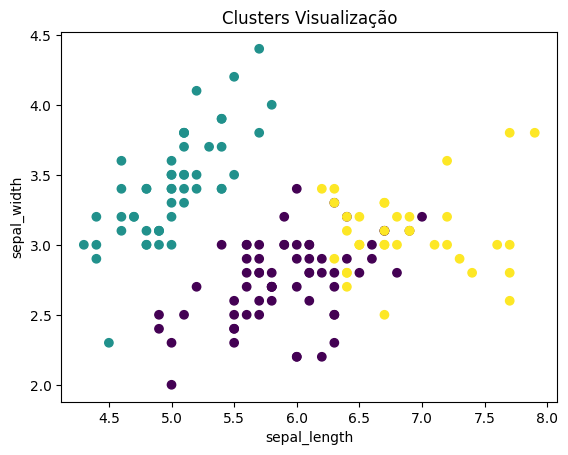

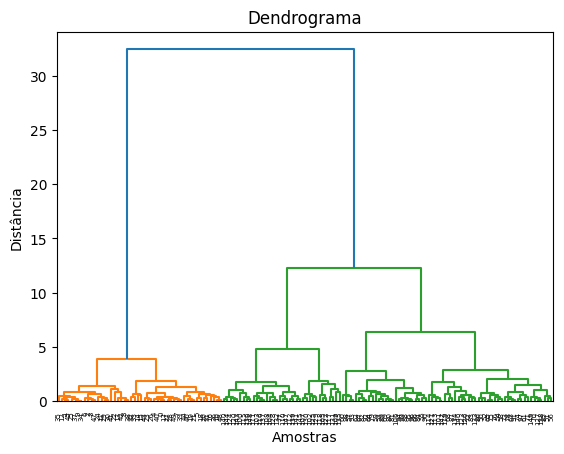

In [4]:
aplicar_agglomerativeCluster(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3, 'euclidean', 'ward')
visualizar_clusters(df[['sepal_length', 'sepal_width']], aplicar_agglomerativeCluster(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3, 'euclidean', 'ward'))
visualizar_dendograma(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 'ward')


In [5]:
metricas_avaliacao(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], aplicar_agglomerativeCluster(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 3, 'euclidean', 'ward'))

Silhouette Score: 0.5540972908150553
Calinski-Harabasz Index: 556.841121636393
Davies-Bouldin Index: 0.6566044124178414
